# Modeling - Patrones de ansiedad

Este notebook aplica clustering y clasificación para identificar patrones en síntomas de ansiedad medidos con BAI.

Objetivos:
- Identificar perfiles de estudiantes basados en síntomas.
- Comparar los clusters con los niveles de ansiedad ya definidos.
- Determinar qué síntomas ayudan a diferenciar los niveles de ansiedad.
- Generar visualizaciones finales claras para comunicar los perfiles y el desempeño del modelo.

## Setup del proyecto

In [1]:
import importlib
import os
import sys
from pathlib import Path

os.environ.setdefault("OMP_NUM_THREADS", "1")

project_root = Path.cwd().resolve()
if project_root.name == "notebooks":
    project_root = project_root.parent

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

importlib.invalidate_caches()
sys.modules.pop("src.config", None)
sys.modules.pop("src.utils", None)

project_root

WindowsPath('C:/dev/bai-analysis')

## Imports

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from src.config import (
    CLUSTER_DATASET_PATH,
    CLUSTER_PROFILE_PATH,
    DATA_CLEANED,
    DATA_PROCESSED,
    FEATURE_IMPORTANCE_PATH,
    OUTPUTS_FIGURES,
    SYMPTOM_CORRELATIONS_PATH,
)
from src.data_loader import load_table
from src.utils import (
    BAI_SYMPTOMS,
    CATEGORY_ORDER,
    CATEGORY_PALETTE,
    CLUSTER_PALETTE,
    assign_ordered_clusters,
    bai_label_map,
    build_cluster_profile,
    build_feature_importance_table,
    build_category_counts,
    build_dataset_summary,
    build_symptom_correlation_table,
    evaluate_kmeans_range,
    export_clustered_dataset,
    export_cluster_profiles,
    export_feature_importance,
    export_symptom_correlations,
    fit_bai_kmeans,
    get_bai_columns,
    polish_axes,
    save_plot as save_plot_to_path,
    summarize_clusters,
    validate_bai_analysis_columns,
    wrap_label,
)

sns.set_theme(style="whitegrid", context="notebook")


def save_plot(fig, filename, dpi=220):
    return save_plot_to_path(fig, filename, OUTPUTS_FIGURES, dpi=dpi)

## Utilidades visuales

In [3]:
short_bai_labels = bai_label_map([f"BAI_{idx}" for idx in range(1, 22)], short=True)

## Cargar y validar datos

In [4]:
SOURCE_DATA_PATH = DATA_CLEANED

df = load_table(SOURCE_DATA_PATH).copy()

bai_cols = get_bai_columns(df)
bai_cols = validate_bai_analysis_columns(df, bai_cols)
summary = build_dataset_summary(df, bai_cols)

display(summary)
display(df.head())
print(f"Fuente cargada para modelado: {SOURCE_DATA_PATH}")

,filas,columnas,síntomas_BAI,score_min,score_mediana,score_max
0,113,26,21,1,16.0,61


,id,age,category,gender,totalScore,BAI_1,BAI_2,BAI_3,BAI_4,BAI_5,...,BAI_12,BAI_13,BAI_14,BAI_15,BAI_16,BAI_17,BAI_18,BAI_19,BAI_20,BAI_21
0,024ccc066e5f36803f8861b9ee3d94888e5370faed41a9...,24,LOW,M,11,1,2,0,0,2,...,0,0,0,0,0,1,0,0,0,2
1,02f2a803fa9512cbee77681b62aec389336d01bf56e54b...,19,LOW,M,15,2,3,0,2,1,...,0,0,0,1,0,0,1,0,0,2
2,044a25cf19eab34fffd83bdd006ce8338150351ac18ebf...,23,LOW,M,16,2,2,0,2,2,...,0,0,1,0,0,2,0,0,0,1
3,05590f956566724748711d0b68f1b44f3fabfc87cab7cf...,25,LOW,M,4,0,0,0,1,1,...,0,0,0,0,0,0,1,0,0,0
4,0ba67bab767aadf47f4be2743015846e30a32459939c76...,23,LOW,M,10,0,1,0,2,2,...,0,0,0,0,1,0,1,0,0,0


Fuente cargada para modelado: C:\dev\bai-analysis\data\processed\BAI_CLEANED.xlsx


## Top síntomas (correlación con ansiedad)

In [5]:
corr_df = build_symptom_correlation_table(df, bai_columns=bai_cols, include_labels=True)
symptom_correlation_path = export_symptom_correlations(
    df,
    SYMPTOM_CORRELATIONS_PATH,
    bai_columns=bai_cols,
)

display(corr_df.head(10))
print(f"Archivo CSV de correlaciones generado en: {symptom_correlation_path}")

,symptom,correlation,label
0,BAI_9,0.738511,Terror o miedo
1,BAI_13,0.730560,Temblor general
2,BAI_15,0.705755,Dificultad para respirar
3,BAI_8,0.674356,Inestabilidad
4,BAI_14,0.662292,Miedo a perder el control
5,BAI_3,0.636196,Temblor en las piernas
6,BAI_12,0.621027,Temblor en las manos
7,BAI_6,0.595800,Mareo o aturdimiento
8,BAI_7,0.593942,Latidos fuertes o rápidos
9,BAI_4,0.571197,Incapacidad para relajarse


Archivo CSV de correlaciones generado en: C:\dev\bai-analysis\data\processed\symptom_correlations.csv


## Distribución del nivel de ansiedad

In [6]:
category_counts = build_category_counts(df, CATEGORY_ORDER)
category_counts

,category,count,percentage
0,LOW,71,62.831858
1,MODERATE,34,30.088496
2,SEVERE,8,7.079646


## Parte 1 - Clustering y perfiles

In [7]:
X = df[bai_cols].copy()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

k_results = evaluate_kmeans_range(X_scaled, range(2, 7), random_state=42, n_init=50)
k_results

,k,inertia,silhouette
0,2,1798.531356,0.234020
1,3,1646.978372,0.174132
2,4,1551.547155,0.121826
3,5,1492.663003,0.107679
4,6,1441.195136,0.086182


Procedimiento reusable para nuevas generaciones de `.csv` o `.xlsx`:

1. Cambia `SOURCE_DATA_PATH` por la nueva tabla procesada.
2. Valida que conserve `totalScore`, `category` y `BAI_1` a `BAI_21`.
3. Reejecuta este bloque para recalcular `k`, ajustar `KMeans`, ordenar clusters por severidad y exportar perfiles.

Se usa `k = 3` porque el objetivo sustantivo es comparar perfiles con los tres niveles BAI del dataset (`LOW`, `MODERATE`, `SEVERE`). La tabla anterior sirve como diagnóstico: si el análisis buscara solo separación geométrica, `k = 2` tiene mejor silhouette en esta muestra.

In [8]:
N_CLUSTERS = 3

df, X, X_scaled, scaler, kmeans = fit_bai_kmeans(
    df,
    bai_columns=bai_cols,
    n_clusters=N_CLUSTERS,
    random_state=42,
    n_init=50,
)

In [9]:
cluster_summary = summarize_clusters(df)
cluster_summary

,n,score_promedio,score_mediana,score_min,score_max,porcentaje
cluster,,,,,,
Cluster 1,62,10.63,11.5,1,19,54.9
Cluster 2,31,23.71,24.0,17,30,27.4
Cluster 3,20,35.70,34.0,27,61,17.7


In [ ]:
cluster_profile = build_cluster_profile(df, bai_columns=bai_cols)
cluster_profile_report_path = export_cluster_profiles(
    df,
    CLUSTER_PROFILE_PATH,
    bai_columns=bai_cols,
    top_n_symptoms=5,
)
cluster_profile_report = load_table(cluster_profile_report_path)
cluster_export_path = export_clustered_dataset(df, CLUSTER_DATASET_PATH)

df_for_excel = df.drop(columns=["cluster_raw"])
df_for_excel.to_excel(DATA_PROCESSED, index=False)

display(cluster_profile_report)
display(cluster_profile.round(2))
## print(f"Archivo CSV con clusters generado en: {cluster_export_path}")
## print(f"Archivo CSV con perfiles generado en: {cluster_profile_report_path}")
## print(f"Archivo Excel procesado actualizado en: {DATA_PROCESSED}")

,cluster,n,porcentaje,score_promedio,score_mediana,categoria_dominante,sintomas_clave
0,Cluster 1,62,54.9,10.63,11.5,LOW,Incapacidad para relajarse (1.26) | Miedo a qu...
1,Cluster 2,31,27.4,23.71,24.0,MODERATE,Sensación de calor (1.77) | Entumecimiento u h...
2,Cluster 3,20,17.7,35.70,34.0,MODERATE,Incapacidad para relajarse (2.50) | Miedo a qu...


,BAI_1,BAI_2,BAI_3,BAI_4,BAI_5,BAI_6,BAI_7,BAI_8,BAI_9,BAI_10,...,BAI_12,BAI_13,BAI_14,BAI_15,BAI_16,BAI_17,BAI_18,BAI_19,BAI_20,BAI_21
cluster,,,,,,,,,,,,,,,,,,,,,
Cluster 1,0.56,1.18,0.19,1.26,1.23,0.26,0.56,0.44,0.26,0.98,...,0.29,0.13,0.45,0.13,0.35,0.37,0.76,0.19,0.34,0.53
Cluster 2,1.68,1.77,0.77,1.45,1.48,1.03,1.29,1.35,1.06,1.58,...,0.61,0.71,1.16,0.68,0.84,1.10,0.90,0.55,1.19,1.55
Cluster 3,1.25,1.85,1.65,2.50,2.45,1.40,1.80,1.85,2.10,2.35,...,1.65,1.65,2.10,1.50,1.55,1.30,2.20,1.00,1.00,1.20


Archivo CSV con clusters generado en: C:\dev\bai-analysis\data\processed\bai_with_clusters.csv
Archivo CSV con perfiles generado en: C:\dev\bai-analysis\data\processed\cluster_profiles.csv
Archivo Excel procesado actualizado en: C:\dev\bai-analysis\data\processed\BAI_PROCESSED.xlsx


In [11]:
cluster_vs_category = pd.crosstab(
    df["cluster"],
    df["category"],
    normalize="index",
).reindex(columns=CATEGORY_ORDER, fill_value=0)

cluster_vs_category_display = (cluster_vs_category * 100).round(1)
cluster_vs_category_display

category,LOW,MODERATE,SEVERE
cluster,,,
Cluster 1,100.0,0.0,0.0
Cluster 2,29.0,71.0,0.0
Cluster 3,0.0,60.0,40.0


## Visualización de clusters

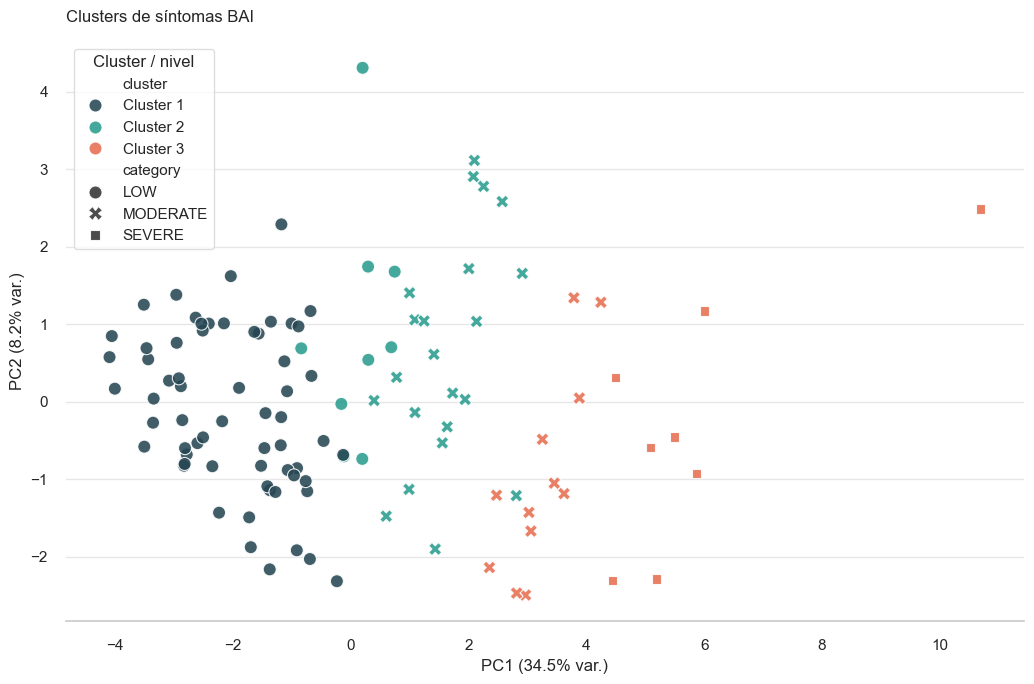

In [12]:
pca = PCA(n_components=2, random_state=42)
pca_values = pca.fit_transform(X_scaled)
df["PC1"] = pca_values[:, 0]
df["PC2"] = pca_values[:, 1]

explained_variance = pca.explained_variance_ratio_ * 100

fig, ax = plt.subplots(figsize=(10.5, 7))
sns.scatterplot(
    data=df,
    x="PC1",
    y="PC2",
    hue="cluster",
    style="category",
    palette=CLUSTER_PALETTE[:N_CLUSTERS],
    s=88,
    alpha=0.88,
    edgecolor="white",
    linewidth=0.8,
    ax=ax,
)
ax.set_title("Clusters de síntomas BAI", loc="left", pad=14)
ax.set_xlabel(f"PC1 ({explained_variance[0]:.1f}% var.)")
ax.set_ylabel(f"PC2 ({explained_variance[1]:.1f}% var.)")
ax.legend(title="Cluster / nivel", frameon=True, facecolor="white", edgecolor="#D6D6D6")
polish_axes(ax)

save_plot(fig, "cluster_pca_scatter.png")
plt.show()

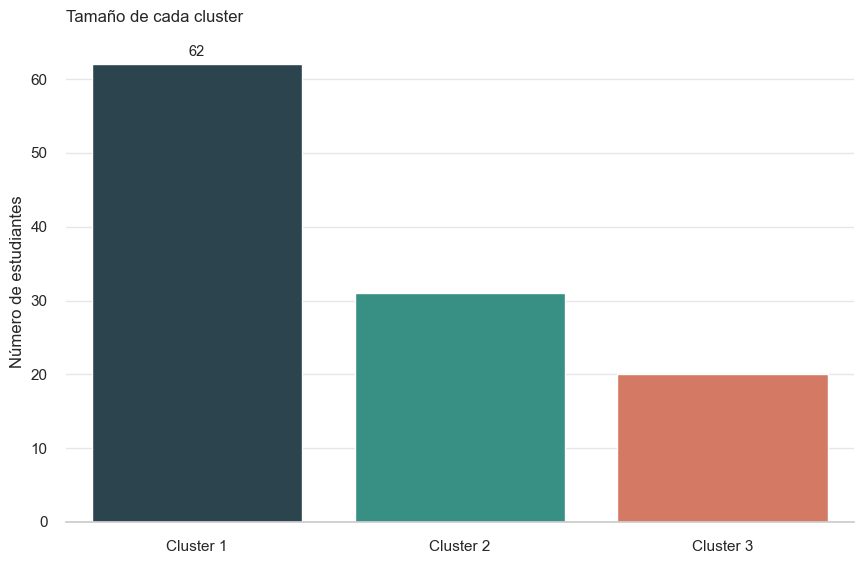

In [13]:
plot_counts = cluster_summary.reset_index()

fig, ax = plt.subplots(figsize=(8.8, 5.8))
sns.barplot(
    data=plot_counts,
    x="cluster",
    y="n",
    hue="cluster",
    palette=CLUSTER_PALETTE[:N_CLUSTERS],
    legend=False,
    ax=ax,
)
ax.bar_label(ax.containers[0], padding=4, fontsize=10.5)
ax.set_title("Tamaño de cada cluster", loc="left", pad=14)
ax.set_xlabel("")
ax.set_ylabel("Número de estudiantes")
polish_axes(ax)

save_plot(fig, "cluster_sizes.png")
plt.show()

## Perfil de síntomas por cluster

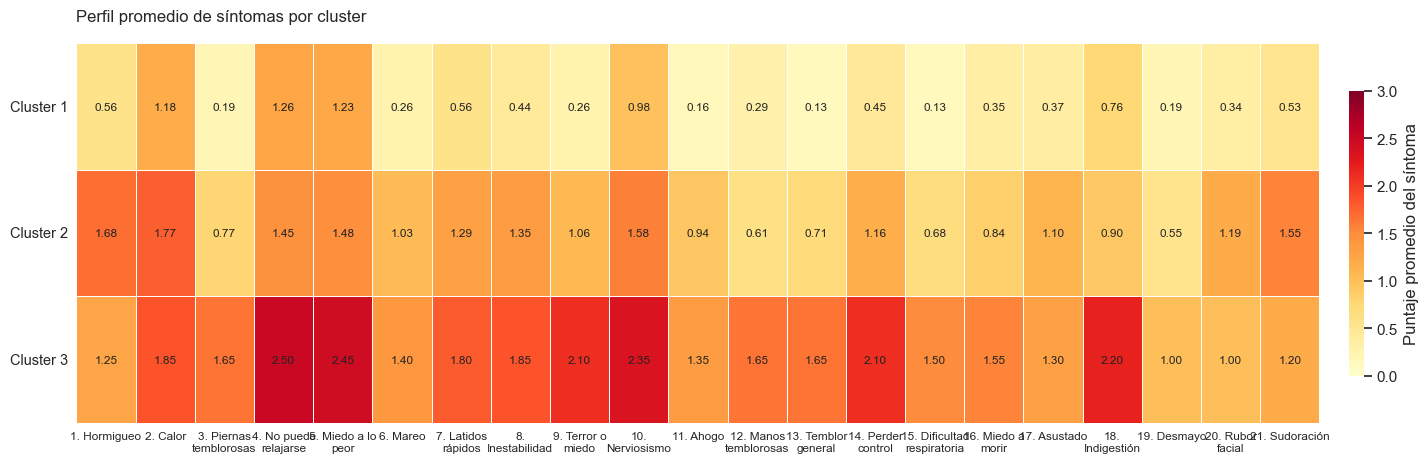

In [14]:
cluster_profile_display = cluster_profile.rename(columns=short_bai_labels)

fig, ax = plt.subplots(figsize=(16, 4.8))
sns.heatmap(
    cluster_profile_display,
    cmap="YlOrRd",
    vmin=0,
    vmax=3,
    linewidths=0.5,
    linecolor="white",
    annot=True,
    fmt=".2f",
    annot_kws={"size": 8.5, "color": "#222222"},
    cbar_kws={"label": "Puntaje promedio del síntoma", "shrink": 0.75, "pad": 0.02},
    ax=ax,
)
ax.set_title("Perfil promedio de síntomas por cluster", loc="left", pad=16)
ax.set_xlabel("")
ax.set_ylabel("")
ax.set_xticklabels([wrap_label(label.get_text(), 14) for label in ax.get_xticklabels()], rotation=0, ha="center", fontsize=8.5)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=10.5)
ax.tick_params(axis="both", length=0, pad=6)

save_plot(fig, "cluster_profiles.png")
plt.show()

## Parte 2 - Clasificación del nivel de ansiedad

In [15]:
y = pd.Categorical(df["category"], categories=CATEGORY_ORDER, ordered=True)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y,
)

clf = RandomForestClassifier(
    n_estimators=500,
    random_state=42,
    class_weight="balanced",
    min_samples_leaf=2,
    n_jobs=-1,
)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy en test: {accuracy:.3f}")
print(classification_report(y_test, y_pred, labels=CATEGORY_ORDER, zero_division=0))

Accuracy en test: 0.793
              precision    recall  f1-score   support

         LOW       0.81      0.94      0.87        18
    MODERATE       0.71      0.56      0.62         9
      SEVERE       1.00      0.50      0.67         2

    accuracy                           0.79        29
   macro avg       0.84      0.67      0.72        29
weighted avg       0.79      0.79      0.78        29



In [16]:
feature_importance = build_feature_importance_table(
    df,
    score_column="totalScore",
    n_estimators=100,
    random_state=42,
)
feature_importance_path = export_feature_importance(
    df,
    FEATURE_IMPORTANCE_PATH,
    score_column="totalScore",
    n_estimators=100,
    random_state=42,
)
feature_importance_display = feature_importance.assign(
    label=feature_importance["symptom"].map(BAI_SYMPTOMS)
)

display(feature_importance_display.head(10))
print(f"Archivo CSV de importancia generado en: {feature_importance_path}")

,symptom,importance,label
0,BAI_13,0.207516,Temblor general
1,BAI_15,0.142385,Dificultad para respirar
2,BAI_9,0.138429,Terror o miedo
3,BAI_8,0.086390,Inestabilidad
4,BAI_14,0.077319,Miedo a perder el control
5,BAI_1,0.051358,Entumecimiento u hormigueo
6,BAI_4,0.040850,Incapacidad para relajarse
7,BAI_12,0.025910,Temblor en las manos
8,BAI_3,0.023423,Temblor en las piernas
9,BAI_7,0.022398,Latidos fuertes o rápidos


Archivo CSV de importancia generado en: C:\dev\bai-analysis\data\processed\feature_importance.csv


## Visualizaciones finales separadas


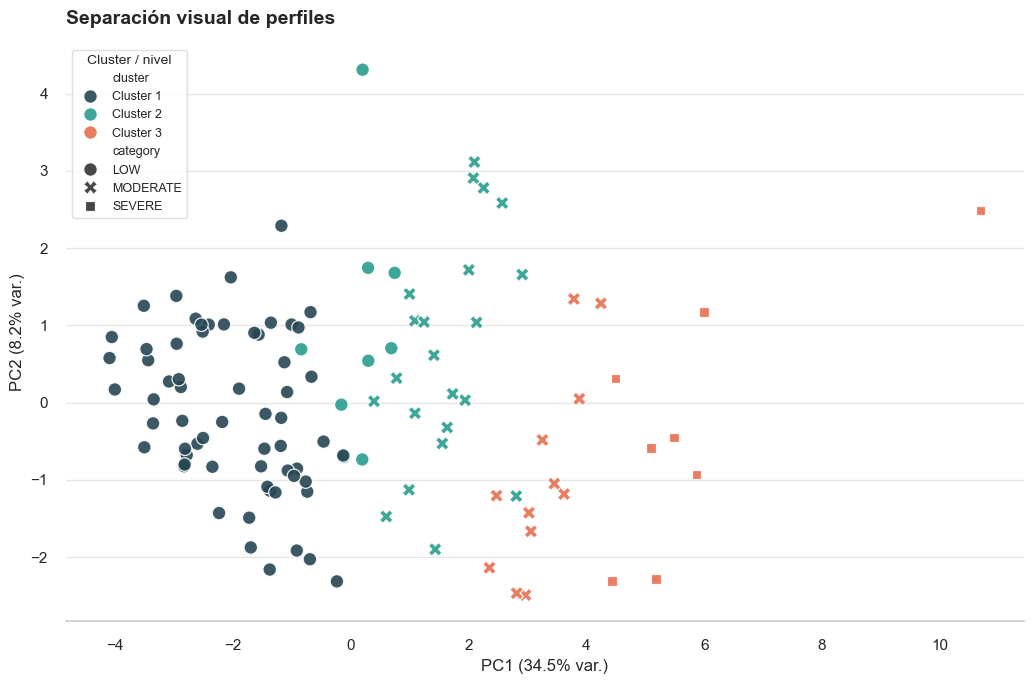

In [17]:
fig, ax = plt.subplots(figsize=(10.5, 7))
sns.scatterplot(
    data=df,
    x="PC1",
    y="PC2",
    hue="cluster",
    style="category",
    palette=CLUSTER_PALETTE[:N_CLUSTERS],
    s=95,
    alpha=0.9,
    edgecolor="white",
    linewidth=0.9,
    ax=ax,
)
ax.set_title("Separación visual de perfiles", loc="left", pad=14, fontsize=14, fontweight="bold")
ax.set_xlabel(f"PC1 ({explained_variance[0]:.1f}% var.)")
ax.set_ylabel(f"PC2 ({explained_variance[1]:.1f}% var.)")
ax.legend(title="Cluster / nivel", frameon=True, facecolor="white", edgecolor="#D6D6D6", fontsize=9, title_fontsize=10)
polish_axes(ax)

save_plot(fig, "final_pca_profiles.png", dpi=240)
plt.show()

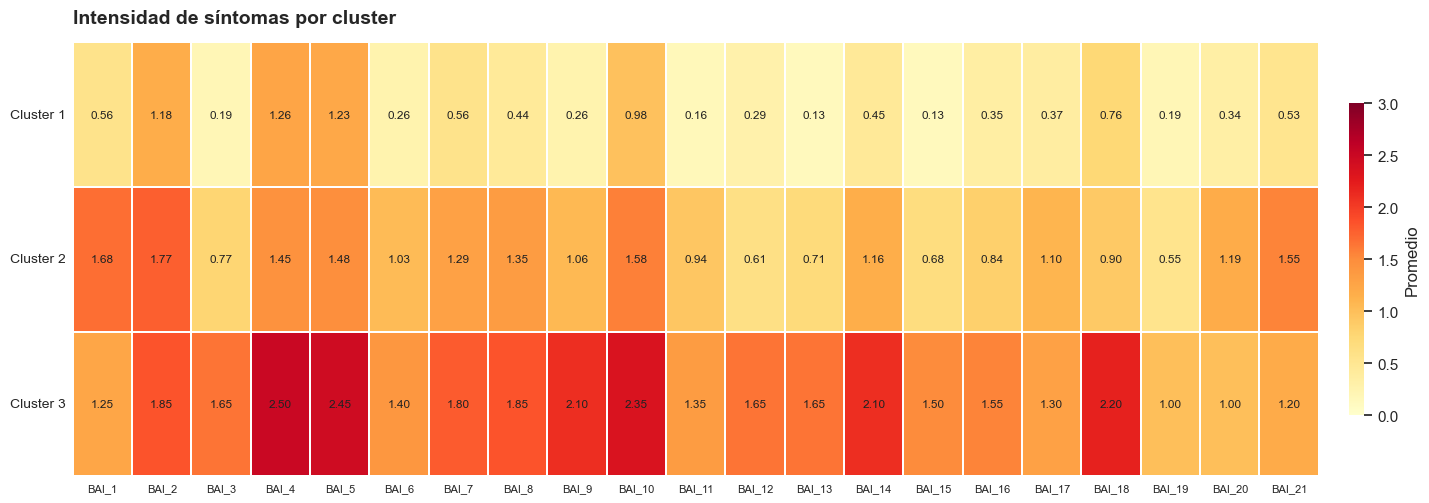

In [18]:
fig, ax = plt.subplots(figsize=(16, 5.2))
sns.heatmap(
    cluster_profile,
    cmap="YlOrRd",
    vmin=0,
    vmax=3,
    linewidths=0.35,
    linecolor="white",
    annot=True,
    fmt=".2f",
    annot_kws={"size": 8.5, "color": "#222222"},
    cbar_kws={"label": "Promedio", "shrink": 0.72, "pad": 0.02},
    ax=ax,
)
ax.set_title("Intensidad de síntomas por cluster", loc="left", pad=14, fontsize=14, fontweight="bold")
ax.set_xlabel("")
ax.set_ylabel("")
ax.set_xticklabels([wrap_label(label.get_text(), 13) for label in ax.get_xticklabels()], rotation=0, ha="center", fontsize=8)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=10)
ax.tick_params(axis="both", length=0, pad=5)

save_plot(fig, "final_cluster_symptom_heatmap.png", dpi=240)
plt.show()

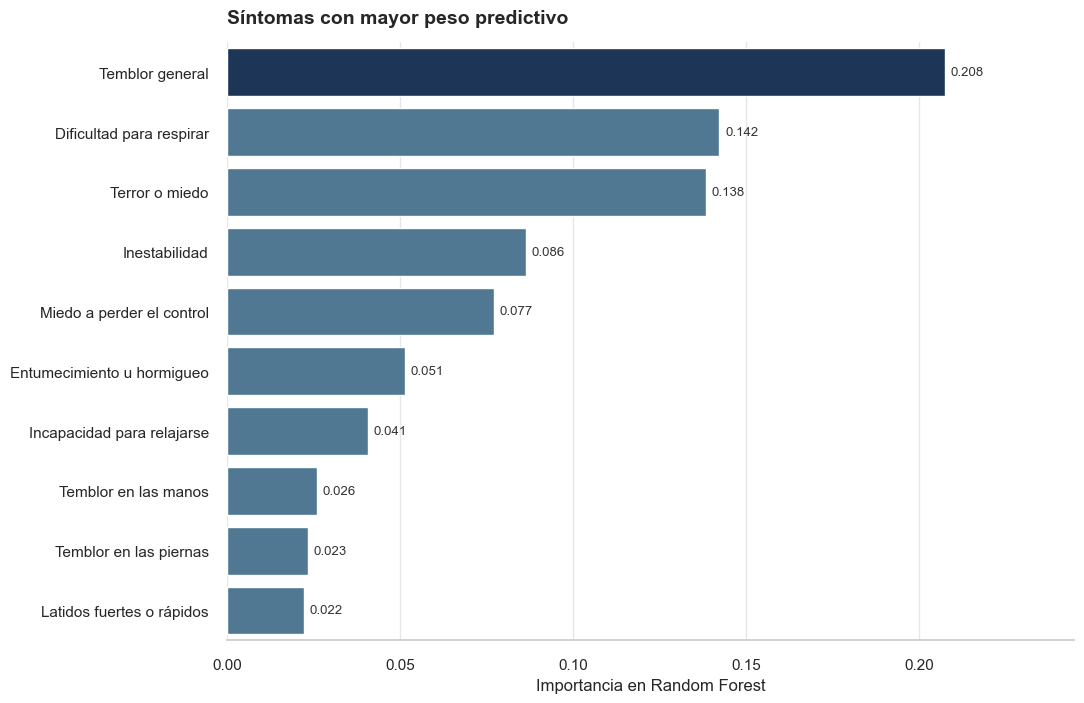

In [19]:
top_n = 10
top_features = feature_importance_display.head(top_n).copy()
top_features["wrapped_label"] = [wrap_label(label, 30) for label in top_features["label"]]

fig, ax = plt.subplots(figsize=(11, 7.2))
sns.barplot(
    data=top_features,
    x="importance",
    y="wrapped_label",
    color="#457B9D",
    ax=ax,
)
if ax.patches:
    ax.patches[0].set_facecolor("#1D3557")
ax.bar_label(
    ax.containers[0],
    labels=[f"{value:.3f}" for value in top_features["importance"]],
    padding=4,
    fontsize=9.5,
    color="#333333",
)
ax.set_title("Síntomas con mayor peso predictivo", loc="left", pad=14, fontsize=14, fontweight="bold")
ax.set_xlabel("Importancia en Random Forest")
ax.set_ylabel("")
ax.set_xlim(0, top_features["importance"].max() * 1.18)
polish_axes(ax, grid_axis="x")

save_plot(fig, "final_feature_importance.png", dpi=240)
plt.show()

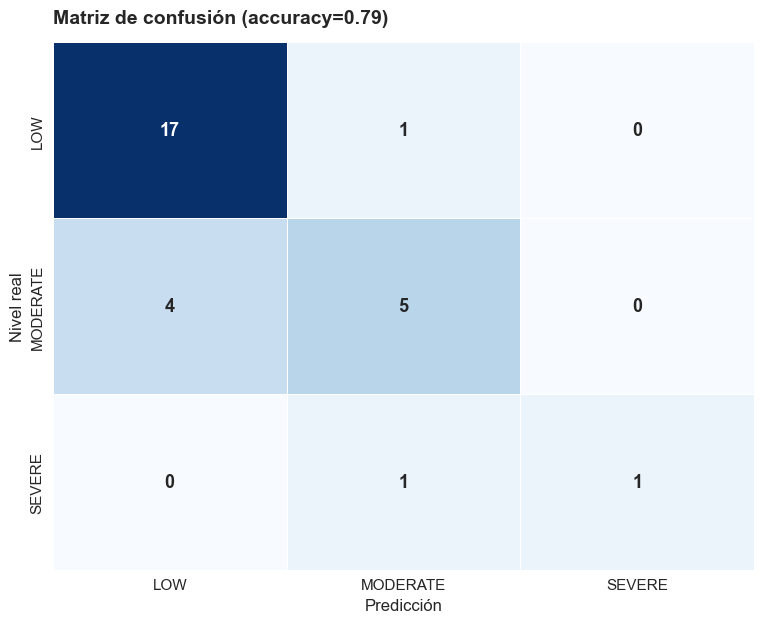

In [20]:
cm = confusion_matrix(y_test, y_pred, labels=CATEGORY_ORDER)

fig, ax = plt.subplots(figsize=(7.8, 6.4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    linewidths=0.6,
    linecolor="white",
    cbar=False,
    xticklabels=CATEGORY_ORDER,
    yticklabels=CATEGORY_ORDER,
    annot_kws={"size": 13, "weight": "bold"},
    ax=ax,
)
ax.set_title(f"Matriz de confusión (accuracy={accuracy:.2f})", loc="left", pad=14, fontsize=14, fontweight="bold")
ax.set_xlabel("Predicción")
ax.set_ylabel("Nivel real")
ax.tick_params(axis="both", length=0, pad=6)

save_plot(fig, "final_confusion_matrix.png", dpi=240)
plt.show()

## Notas de interpretación

- `totalScore` no se usa como predictor en la clasificación porque es la suma directa de los 21 ítems BAI y filtraría la respuesta al modelo.
- La clase `SEVERE` tiene pocos casos; por eso el desempeño de clasificación debe interpretarse con cautela.
- El clustering usa `k = 3` para mantener la comparación sustantiva con los tres niveles de ansiedad, aunque el diagnóstico de silhouette sugiere revisar `k = 2` si el objetivo cambia a separación geométrica pura.